Load Dataset

In [1]:
import json
import pandas as pd

with open("../data/processed/combined_chunks.json", "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

df.head()

,chunk_id,text,page,section,label,company_name
0,1,Generative AI and You Integrated Annual Report...,1,corporate,Corporate_Overview,Infosys
1,2,Gen AI: Ushering in the next era of business W...,2,sustainability,Sustainability,Infosys
2,3,Microsoft Corporation: Transforming platform e...,3,sustainability,Sustainability,Infosys
3,4,Danske Bank: Scaling assistive technology orga...,4,sustainability,Sustainability,Infosys
4,5,Currys: Driving step-change evolution of sales...,5,sustainability,Sustainability,Infosys


In [2]:
print("Dataset size:", len(df))
print("\nColumns:")
print(df.columns)

print("\nClass distribution:")
print(df["label"].value_counts())

Dataset size: 1418

Columns:
Index(['chunk_id', 'text', 'page', 'section', 'label', 'company_name'], dtype='str')

Class distribution:
label
Financial_Statements     964
Sustainability           307
Governance                92
Management_Discussion     29
Risk_Management           20
Corporate_Overview         6
Name: count, dtype: int64


Check Text Length (for error analysis)

In [3]:
df["text_length"] = df["text"].apply(lambda x: len(x.split()))

print(df["text_length"].describe())

count    1418.000000
mean      392.622003
std       170.832503
min         4.000000
25%       272.000000
50%       413.000000
75%       559.000000
max       600.000000
Name: text_length, dtype: float64


Load Your Classical Model

In [4]:
import joblib

model = joblib.load("../baseline_model.pkl")

print("Model loaded successfully")

Model loaded successfully


Preparing Text for Prediction

In [5]:
texts = df["text"]
true_labels = df["label"]

Vectorizer

In [6]:
import joblib

vectorizer = joblib.load("../tfidf_vectorizer.pkl")

print("Vectorizer loaded successfully")

Vectorizer loaded successfully


Convert Text to TF-IDF

In [7]:
X = vectorizer.transform(texts)

Predict Labels

In [8]:
predictions = model.predict(X)

df["predicted_label"] = predictions

df.head()

,chunk_id,text,page,section,label,company_name,text_length,predicted_label
0,1,Generative AI and You Integrated Annual Report...,1,corporate,Corporate_Overview,Infosys,8,Other
1,2,Gen AI: Ushering in the next era of business W...,2,sustainability,Sustainability,Infosys,464,Other
2,3,Microsoft Corporation: Transforming platform e...,3,sustainability,Sustainability,Infosys,396,Sustainability
3,4,Danske Bank: Scaling assistive technology orga...,4,sustainability,Sustainability,Infosys,415,Sustainability
4,5,Currys: Driving step-change evolution of sales...,5,sustainability,Sustainability,Infosys,362,Sustainability


Finding Errors

In [9]:
errors = df[df["label"] != df["predicted_label"]]

print("Total errors:", len(errors))

Total errors: 199


View Some Misclassified Examples

In [10]:
errors[["text", "label", "predicted_label"]].sample(5)

,text,label,predicted_label
504,Notice 56 57 Notice (A) The transactions that ...,Financial_Statements,Other
842,Social and Relationship VALUE CREATION FOR STA...,Financial_Statements,Sustainability
496,Notice 50 51 Notice Helpdesk for Individual Sh...,Financial_Statements,Sustainability
921,VALUE CREATION FOR STAKEHOLDERS RISK MANAGEMEN...,Financial_Statements,Governance
149,Infosys share price versus the S&P BSE Sensex ...,Financial_Statements,Governance


Confusion Matrix

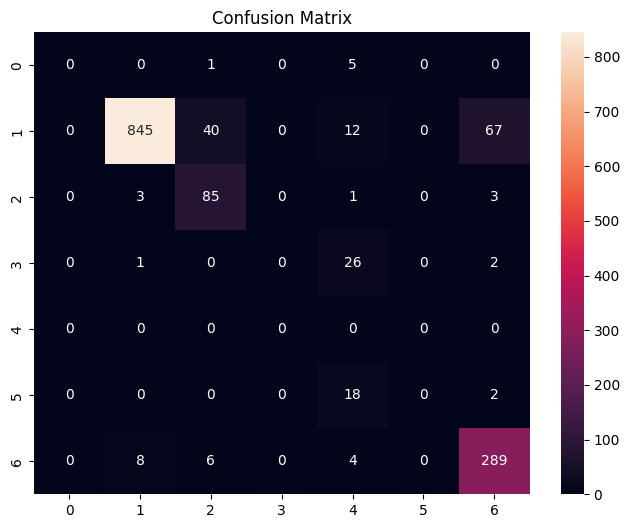

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(df["label"], df["predicted_label"])

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

## For Transformer Model Evaluation

Load Model

In [14]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load tokenizer from base model
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Load trained model from checkpoint
model = AutoModelForSequenceClassification.from_pretrained(
    "../results/checkpoint-284"
)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2080.15it/s]


Generate Predictions

In [15]:
texts = df["text"].tolist()
true_labels = df["label"].tolist()

Tokenize the Text

In [19]:
inputs = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=256,
    return_tensors="pt"
)

Run the Model (prediction in batches)

In [21]:
import torch
from torch.utils.data import DataLoader

batch_size = 16

all_predictions = []

model.eval()

for i in range(0, len(texts), batch_size):

    batch_texts = texts[i:i+batch_size]

    inputs = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=256,   # faster than 512
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = model(**inputs)

    preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
    all_predictions.extend(preds)

predictions = all_predictions

Recreate the Label Mapping

In [23]:
label_map = dict(enumerate(df["label"].astype("category").cat.categories))
print(label_map)

{0: 'Corporate_Overview', 1: 'Financial_Statements', 2: 'Governance', 3: 'Management_Discussion', 4: 'Risk_Management', 5: 'Sustainability'}


Convert Predictions to Text Labels

In [24]:
predictions_text = [label_map[p] for p in predictions]

Classification Report

In [25]:
from sklearn.metrics import classification_report

print(classification_report(true_labels, predictions_text))

                       precision    recall  f1-score   support

   Corporate_Overview       0.00      0.00      0.00         6
 Financial_Statements       0.90      0.95      0.93       964
           Governance       0.00      0.00      0.00        92
Management_Discussion       0.00      0.00      0.00        29
      Risk_Management       0.00      0.00      0.00        20
       Sustainability       0.67      0.89      0.77       307

             accuracy                           0.84      1418
            macro avg       0.26      0.31      0.28      1418
         weighted avg       0.76      0.84      0.80      1418



c:\Users\Dell\intelligent-document-analyzer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\intelligent-document-analyzer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\intelligent-document-analyzer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

Confusion Matrix

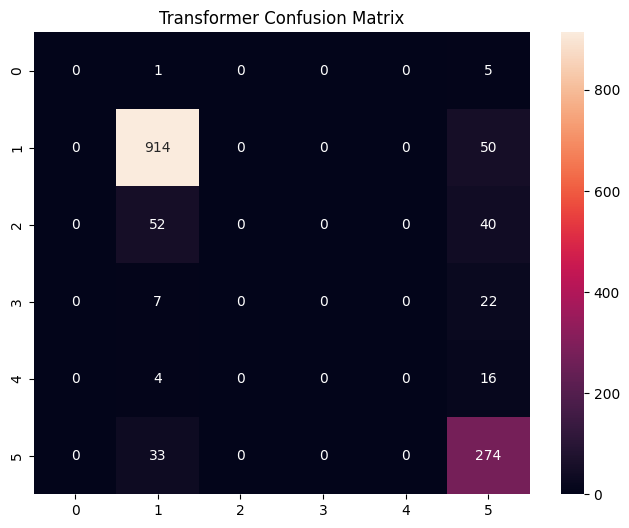

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions_text)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Transformer Confusion Matrix")
plt.show()